## Entraînement d'un SVM avec SkLearn

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.datasets import load_iris

#### Import des données

In [16]:
flowers = load_iris(as_frame=True).data
target = load_iris(as_frame=True).target
target = pd.DataFrame(target)

#### Visualisation des données

In [19]:
types_fleurs, nb_fleurs = np.unique(target, return_counts=True)

([<matplotlib.patches.Wedge at 0x2663fc09d00>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Setosa'),
  Text(-1.0999999999999954, -1.0298943258065002e-07, 'Virginica'),
  Text(0.5500001486524352, -0.9526278583383436, 'Versicolor')])

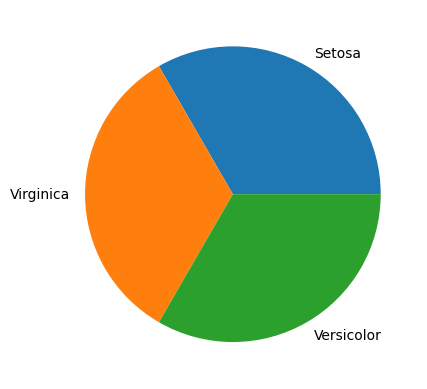

In [21]:
plt.pie(nb_fleurs, labels = ['Setosa', 'Virginica', 'Versicolor'])

### Pipeline + GridSearchCV

In [24]:
Pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

In [26]:
param_grid = [
    {
        'scaler' : [StandardScaler(), MinMaxScaler()],
        'svc__C' : np.arange(10, 30, 1),
        'svc__kernel' : ['poly'],
        'svc__degree' : [2, 3, 4, 5]
    },
    {
        'scaler' : [StandardScaler(), MinMaxScaler()],
        'svc__C' : np.arange(10, 30, 1),
        'svc__kernel' : ['linear']
    },
    {
        'scaler' : [StandardScaler(), MinMaxScaler()],
        'svc__C' : np.arange(10, 30, 1),
        'svc__kernel' : ['poly', 'rbf', 'sigmoid'],
        'svc__gamma' : ['scale', 'auto']
    }
]

In [28]:
grid = GridSearchCV(
    estimator = Pipe,
    param_grid = param_grid,
    scoring = 'accuracy',
    cv = StratifiedKFold(3), # On prend 3 petits folds car le dataset est assez petit
    n_jobs = 4 # On mobilise 4 coeurs du processeurs pour la parallélisation des tâches lors de l'entraînement
)

#### Train_Test_Split

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(flowers, target.to_numpy().ravel(), test_size=0.2, random_state=42, shuffle=True)

### Entraînement du modèle de SVM

In [34]:
grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC())]),
             n_jobs=4,
             param_grid=[{'scaler': [StandardScaler(), MinMaxScaler()],
                          'svc__C': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                          'svc__degree': [2, 3, 4, 5],
                          'svc__kernel': ['poly']},
                         {'scaler': [StandardScaler(), MinMaxScaler()],
                          'svc__C': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                          'svc__kernel': ['linear']},
                         {'scaler': [StandardScaler(), MinMaxScaler()],
                          'svc__C': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                          'svc__gamma': ['scale', 'auto'],
                          'svc__kernel': ['poly', 'rbf', 'sigmoid']}],
             scoring='accuracy')

In [35]:
grid.best_params_

{'scaler': MinMaxScaler(),
 'svc__C': 20,
 'svc__gamma': 'auto',
 'svc__kernel': 'sigmoid'}

In [37]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

### Visualisation de nos prédictions

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [50]:
print("Accuracy test :", accuracy_score(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

Accuracy test : 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



Text(50.722222222222214, 0.5, 'Predictions')

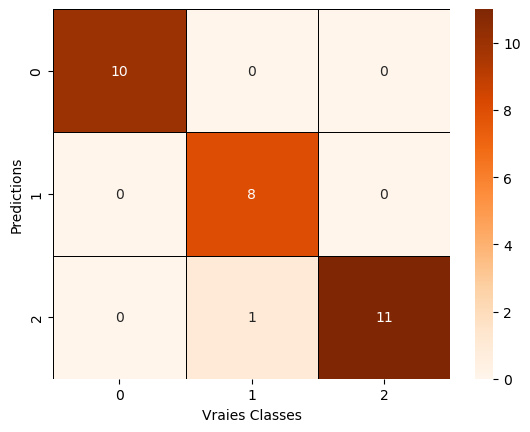

In [104]:
cm = confusion_matrix(y_pred, Y_test)
sns.heatmap(cm, annot=True, linecolor="black", linewidth=0.5, cmap='Oranges')
plt.xlabel("Vraies Classes")
plt.ylabel("Predictions")